## Imports

In [24]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

## Setting dataset path

In [10]:
DATASET_DIR = "/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3"

print("Dataset exists:", os.path.exists(DATASET_DIR))
print("Dataset directory:", DATASET_DIR)
print("Top-level files/folders:", os.listdir(DATASET_DIR)[:20])

Dataset exists: True
Dataset directory: /kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3
Top-level files/folders: ['labels', 'images']


## Detecting folder structure and its content

In [11]:
def find_all_files(root_dir, ext):
    all_files = []
    for root, _, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith(ext):
                all_files.append(os.path.join(root, f))
    return all_files

png_files = find_all_files(DATASET_DIR, ".png")
json_files = find_all_files(DATASET_DIR, ".json")

print("Total PNG files found:", len(png_files))
print("Total JSON files found:", len(json_files))

print("\nSample PNG paths:")
for p in png_files[:5]:
    print(p)

print("\nSample JSON paths:")
for j in json_files[:5]:
    print(j)

Total PNG files found: 12738
Total JSON files found: 12738

Sample PNG paths:
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images/nepal-flooding_00000081_post_disaster.png
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images/portugal-wildfire_00000297_post_disaster.png
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images/pinery-bushfire_00001094_post_disaster.png
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images/tuscaloosa-tornado_00000320_post_disaster.png
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images/portugal-wildfire_00000202_post_disaster.png

Sample JSON paths:
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/labels/portugal-wildfire_00000108_pre_disaster.json
/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/labels/woolsey-fire_00000859_post_disaster.json
/kaggle/input/datasets/tunguz/xview

## pre and post images

In [12]:
pre_images = [p for p in png_files if "pre_disaster" in p]
post_images = [p for p in png_files if "post_disaster" in p]

print("Pre-disaster images:", len(pre_images))
print("Post-disaster images:", len(post_images))

if len(pre_images) > 0:
    print("\nExample pre image:", pre_images[0])

if len(post_images) > 0:
    print("Example post image:", post_images[0])

Pre-disaster images: 6369
Post-disaster images: 6369

Example pre image: /kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images/pinery-bushfire_00000250_pre_disaster.png
Example post image: /kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images/nepal-flooding_00000081_post_disaster.png


## Labels JSON files

In [13]:
label_jsons = [j for j in json_files if "labels" in j or "label" in j]
print("Potential label JSON files:", len(label_jsons))

if len(label_jsons) > 0:
    print("Example label JSON:", label_jsons[0])

Potential label JSON files: 12738
Example label JSON: /kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/labels/portugal-wildfire_00000108_pre_disaster.json


## Displaying random pre and post image pairs

Pre: /kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images/nepal-flooding_00000019_pre_disaster.png
Post: /kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images/nepal-flooding_00000019_post_disaster.png


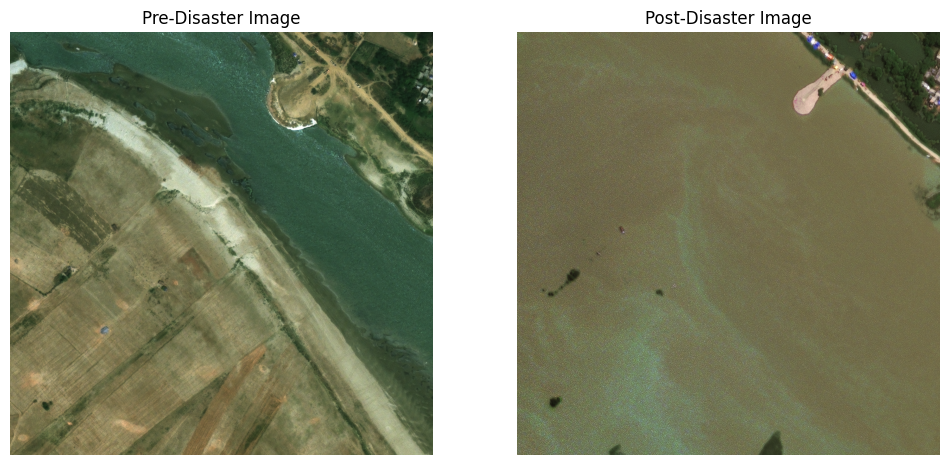

In [20]:
def show_pre_post(pre_path, post_path):
    pre_img = Image.open(pre_path)
    post_img = Image.open(post_path)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(pre_img)
    plt.title("Pre-Disaster Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(post_img)
    plt.title("Post-Disaster Image")
    plt.axis("off")

    plt.show()

sample_post = random.choice(post_images)
sample_pre = sample_post.replace("post_disaster", "pre_disaster")

print("Pre:", sample_pre)
print("Post:", sample_post)

if os.path.exists(sample_pre):
    show_pre_post(sample_pre, sample_post)
else:
    print("Matching pre image not found for this post image.")

## Checking image dimension distribution

### Pre disaster images dimension check

        width  height
count   200.0   200.0
mean   1024.0  1024.0
std       0.0     0.0
min    1024.0  1024.0
25%    1024.0  1024.0
50%    1024.0  1024.0
75%    1024.0  1024.0
max    1024.0  1024.0


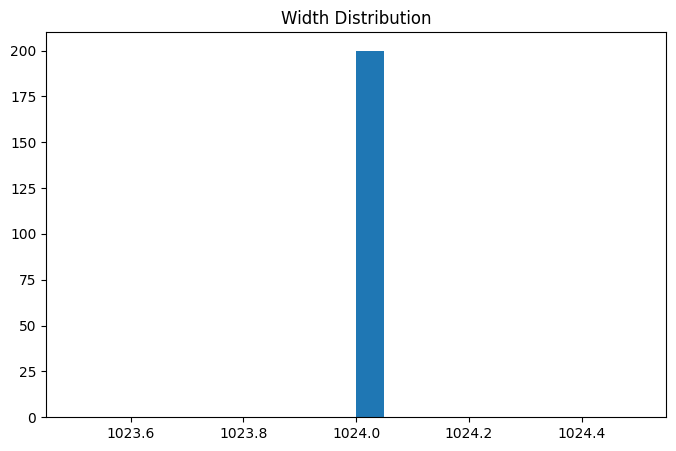

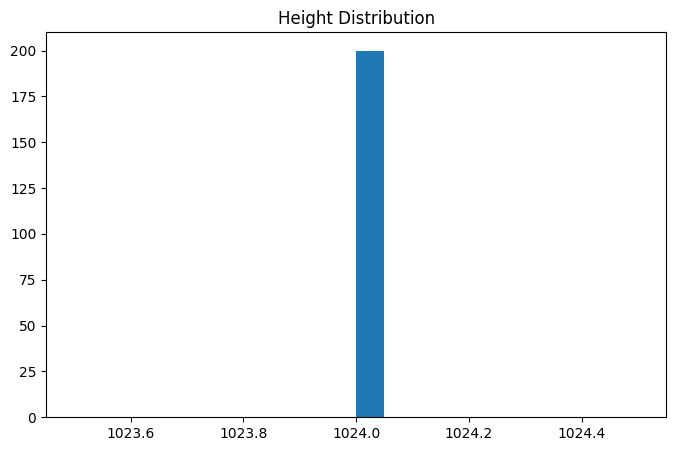

In [25]:
sizes = []

for p in random.sample(pre_images, min(200, len(pre_images))):
    img = Image.open(p)
    sizes.append(img.size)

sizes_df = pd.DataFrame(sizes, columns=["width", "height"])
print(sizes_df.describe())

plt.figure(figsize=(8, 5))
plt.hist(sizes_df["width"], bins=20)
plt.title("Width Distribution")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(sizes_df["height"], bins=20)
plt.title("Height Distribution")
plt.show()

### Post disaster images dimension check

        width  height
count   200.0   200.0
mean   1024.0  1024.0
std       0.0     0.0
min    1024.0  1024.0
25%    1024.0  1024.0
50%    1024.0  1024.0
75%    1024.0  1024.0
max    1024.0  1024.0


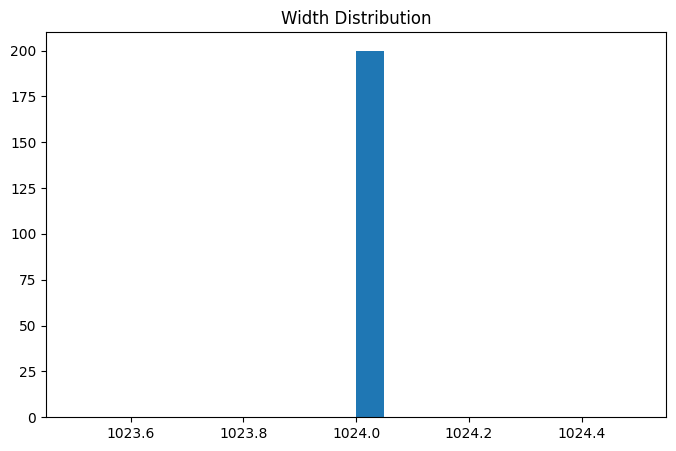

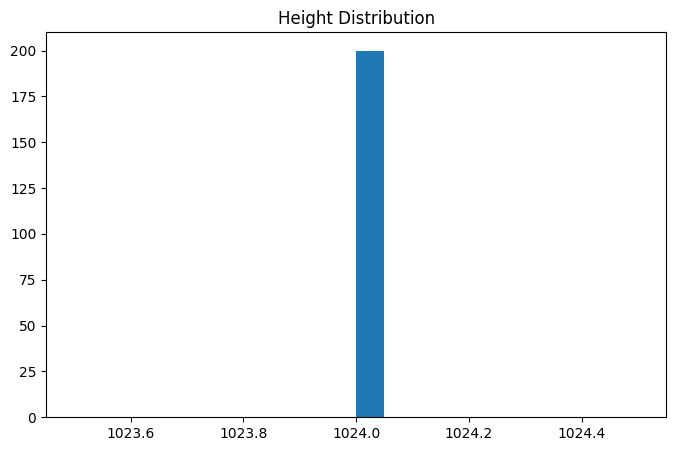

In [26]:
sizes = []

for p in random.sample(post_images, min(200, len(post_images))):
    img = Image.open(p)
    sizes.append(img.size)

sizes_df = pd.DataFrame(sizes, columns=["width", "height"])
print(sizes_df.describe())

plt.figure(figsize=(8, 5))
plt.hist(sizes_df["width"], bins=20)
plt.title("Width Distribution")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(sizes_df["height"], bins=20)
plt.title("Height Distribution")
plt.show()

- All sampled post-disaster images and pre-disaster images have exactly the same resolution: 1024 X 1024, so the mean/min/max are identical. 

- That's why the standard deviation is 0 and the width/height histograms show a single fixed value.

## Summary

In [27]:
print("EDA Complete.")
print("Total pre images:", len(pre_images))
print("Total post images:", len(post_images))
print("Total JSON label files:", len(label_jsons))

EDA Complete.
Total pre images: 6369
Total post images: 6369
Total JSON label files: 12738


- The JSON labels contain pre and post labels corresponding to the respective pre and post disaster images. That means that we have got ourselves total 6369 pre-disaster JSON labels and 6369 post-disaster JSON labels.